# Survival analysis across all 7 signals

How long do businesses in each signal class typically last? Do leading-signal businesses (yoga, specialty coffee, wine bars, pilates) churn faster than counter-signal incumbents (auto repair, print shops)? Do early cohorts in gentrifying neighborhoods survive longer than late cohorts (less competition then) and how does that pattern differ across neighborhoods?

Three views per signal: cohort survival curves (one line per opening year), median lifespan by cohort, and 5-year survival rate by cohort. Then cross-signal and neighborhood comparisons. Findings summary at the end.

Pipeline prerequisites (run from project root):
```
python -m pipelines.load_licences
python -m pipelines.classify_categories
python -m pipelines.geocode
```

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from datetime import date
import duckdb
import matplotlib.pyplot as plt
import polars as pl

from signals.leading.yoga_studios import get_signal as get_yoga
from signals.leading.specialty_coffee import get_signal as get_coffee
from signals.leading.wine_bars import get_signal as get_wine
from signals.leading.pilates_studios import get_signal as get_pilates
from signals.counter.auto_repair import get_signal as get_auto
from signals.counter.print_shops import get_signal as get_print
from signals.anchor.whole_foods_openings import get_signal as get_wf
from signals.analytics import cohort_survival_curve, median_lifespan_by_cohort, n_year_survival_rate
from viz.style import apply as apply_style, signal_color, class_color

apply_style()

CHART_DIR = ROOT / 'analysis' / 'composite_index' / 'weekend_2_charts'
CHART_DIR.mkdir(parents=True, exist_ok=True)

con = duckdb.connect(str(ROOT / 'vancouver_signals.duckdb'), read_only=True)

SIGNALS = {
    'yoga_studios': get_yoga,
    'specialty_coffee': get_coffee,
    'wine_bars': get_wine,
    'pilates_studios': get_pilates,
    'auto_repair': get_auto,
    'print_shops': get_print,
    'whole_foods_openings': get_wf,
}

# Pre-load every signal once. Drop left-censored upfront because they distort cohort math.
data = {name: fn(con).filter(~pl.col('is_left_censored')) for name, fn in SIGNALS.items()}
for name, df in data.items():
    print(f'  loaded {name}: {df.height} businesses (after dropping left-censored)')

  loaded yoga_studios: 154 businesses (after dropping left-censored)
  loaded specialty_coffee: 1292 businesses (after dropping left-censored)
  loaded wine_bars: 24 businesses (after dropping left-censored)
  loaded pilates_studios: 55 businesses (after dropping left-censored)
  loaded auto_repair: 1248 businesses (after dropping left-censored)
  loaded print_shops: 448 businesses (after dropping left-censored)
  loaded whole_foods_openings: 3 businesses (after dropping left-censored)


## Summary table

In [2]:
# We compute the summary against the *unfiltered* signal output so the % left-censored is
# meaningful. Everything downstream uses the post-filter `data` dict.
rows = []
for name, fn in SIGNALS.items():
    df = fn(con)
    rows.append({
        'signal': name,
        'class': df['signal_class'].unique().to_list()[0],
        'total': df.height,
        'left_censored': int(df['is_left_censored'].sum()),
        'pct_left_censored': round(100 * df['is_left_censored'].sum() / df.height, 1) if df.height else 0,
        'with_closure': int(df['closure_date'].is_not_null().sum()),
        'pct_with_closure': round(100 * df['closure_date'].is_not_null().sum() / df.height, 1) if df.height else 0,
    })
summary_df = pl.DataFrame(rows)
with pl.Config(tbl_cols=-1):
    print(summary_df)

shape: (7, 7)
┌────────────────┬─────────┬───────┬───────────────┬────────────────┬──────────────┬───────────────┐
│ signal         ┆ class   ┆ total ┆ left_censored ┆ pct_left_censo ┆ with_closure ┆ pct_with_clos │
│ ---            ┆ ---     ┆ ---   ┆ ---           ┆ red            ┆ ---          ┆ ure           │
│ str            ┆ str     ┆ i64   ┆ i64           ┆ ---            ┆ i64          ┆ ---           │
│                ┆         ┆       ┆               ┆ f64            ┆              ┆ f64           │
╞════════════════╪═════════╪═══════╪═══════════════╪════════════════╪══════════════╪═══════════════╡
│ yoga_studios   ┆ leading ┆ 154   ┆ 0             ┆ 0.0            ┆ 36           ┆ 23.4          │
│ specialty_coff ┆ leading ┆ 1352  ┆ 60            ┆ 4.4            ┆ 728          ┆ 53.8          │
│ ee             ┆         ┆       ┆               ┆                ┆              ┆               │
│ wine_bars      ┆ leading ┆ 25    ┆ 1             ┆ 4.0            ┆ 15     

## Methodology note

**Cohort.** A business belongs to the cohort defined by the year of its `establishment_date`. The 2010 cohort = every business whose first observed licence issuance was in 2010.

**Survival.** A business is "still operating at year Y" if its `closure_date` is null OR its `closure_date` is later than December 31 of year Y. Closure_date itself comes from licence statuses (`Gone Out of Business`, `Inactive`, `Cancelled`) on the most recent licence row, with the assumption documented in `signals/_common.py`.

**Closure detection caveat.** Manual spot-checks (`analysis/composite_index/spot_checks/`) show that the closure heuristic has both false-positive and false-negative rates. The signal under-counts closures most severely (a business that simply stops renewing without an explicit closed-status licence row is invisible to the heuristic). Treat absolute survival rates as upper bounds.

**Right-censoring.** Businesses opened recently haven't had time to close. A 2024 cohort's 5-year survival rate is uncomputable today (we'd need to wait until 2029). The `n_year_survival_rate` function silently drops cohorts younger than the survival window. For general cross-signal comparison we exclude cohorts younger than 3 years.

**Left-censoring.** We pre-filter every signal to drop businesses with `is_left_censored=True` (establishment_date <= 1997). They sit at the cliff of our observation window and their establishment_date is the year we first saw them, not the year they actually opened.

**Median-lifespan note.** `median_lifespan_by_cohort` only uses businesses that have closed. This biases the median downward for old cohorts (their longest-lived members may not yet have closed) but more importantly biases it heavily downward for any cohort: short-lived businesses are over-represented because long-lived ones are missing from the numerator. Read more as "how quickly do the doomed businesses fail" than "typical lifespan."

In [3]:
def plot_signal_three_views(name, df, *, cohort_step=3, min_cohort_size=5):
    """Three-panel survival chart for one signal."""
    color = signal_color(name)

    cohort_years = sorted(df.with_columns(pl.col('establishment_date').dt.year().alias('y'))['y'].unique().to_list())
    sampled = [y for i, y in enumerate(cohort_years) if i % cohort_step == 0]
    today_year = date.today().year
    sampled = [y for y in sampled if y <= today_year - 3]

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

    cmap = plt.get_cmap('viridis')
    if sampled:
        for i, cy in enumerate(sampled):
            curve = cohort_survival_curve(df, cy, max_years=20)
            if int(curve['n_at_risk'][0]) < min_cohort_size:
                continue
            axes[0].plot(curve['years_since_opening'], curve['pct_surviving'],
                         label=str(cy), color=cmap(i / max(1, len(sampled) - 1)), alpha=0.85)
    axes[0].set_title(f'{name}: cohort survival curves')
    axes[0].set_xlabel('Years since opening')
    axes[0].set_ylabel('% surviving')
    axes[0].set_ylim(0, 1.05)
    if sampled:
        axes[0].legend(fontsize=8, ncol=2, loc='lower left', title='Cohort')

    ml = median_lifespan_by_cohort(df).filter(pl.col('median_lifespan_years').is_not_null())
    if ml.height:
        axes[1].plot(ml['cohort_year'], ml['median_lifespan_years'], color=color, marker='o', markersize=4)
    axes[1].set_title(f'{name}: median lifespan of closed businesses')
    axes[1].set_xlabel('Cohort year')
    axes[1].set_ylabel('Median lifespan (years)')

    surv = n_year_survival_rate(df, n_years=5)
    if surv.height:
        axes[2].plot(surv['cohort_year'], surv['pct_surviving_at_n'], color=color, marker='o', markersize=4)
    axes[2].set_title(f'{name}: 5-year survival by cohort')
    axes[2].set_xlabel('Cohort year')
    axes[2].set_ylabel('% still operating after 5 years')
    axes[2].set_ylim(0, 1.05)

    fig.tight_layout()
    out = CHART_DIR / f'{name}_survival.png'
    fig.savefig(out, bbox_inches='tight')
    print(f'  saved {out.relative_to(ROOT)}')
    plt.show()

## Yoga studios

  saved analysis/composite_index/weekend_2_charts/yoga_studios_survival.png


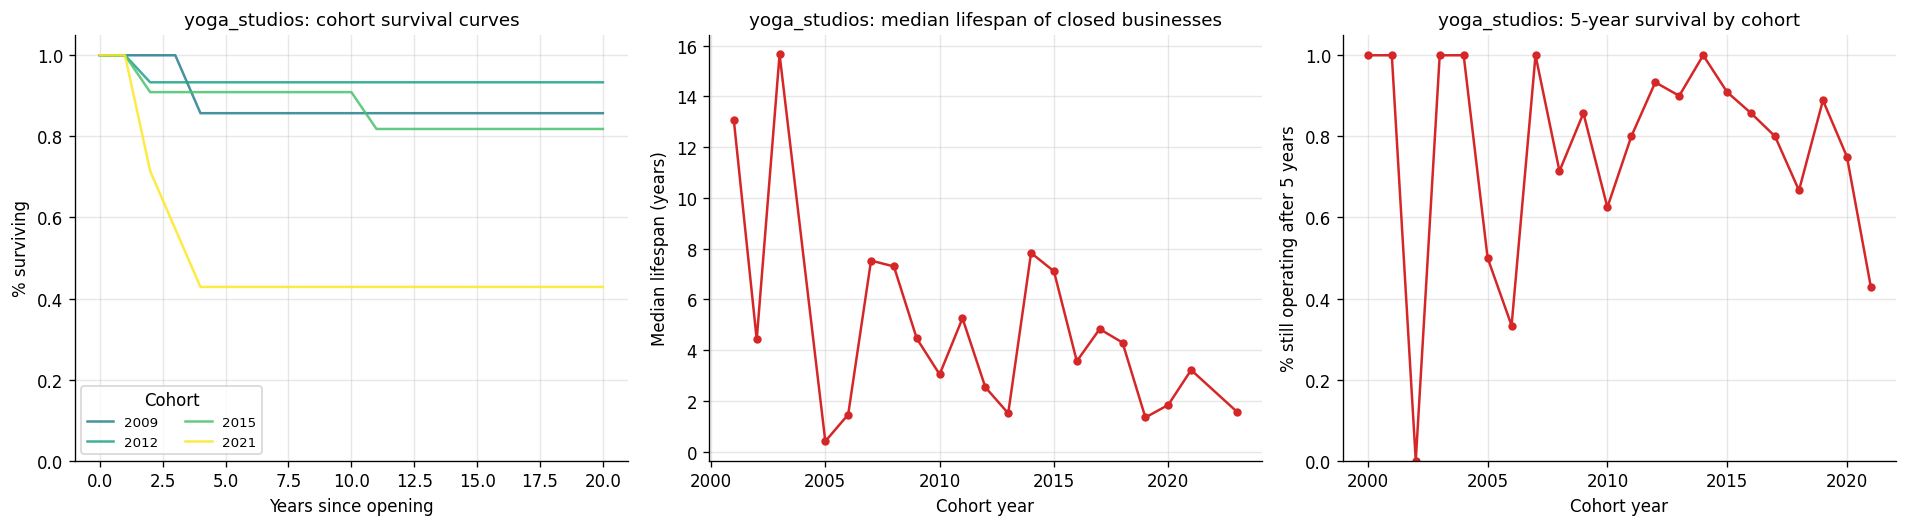

In [4]:
plot_signal_three_views('yoga_studios', data['yoga_studios'])

## Specialty coffee

  saved analysis/composite_index/weekend_2_charts/specialty_coffee_survival.png


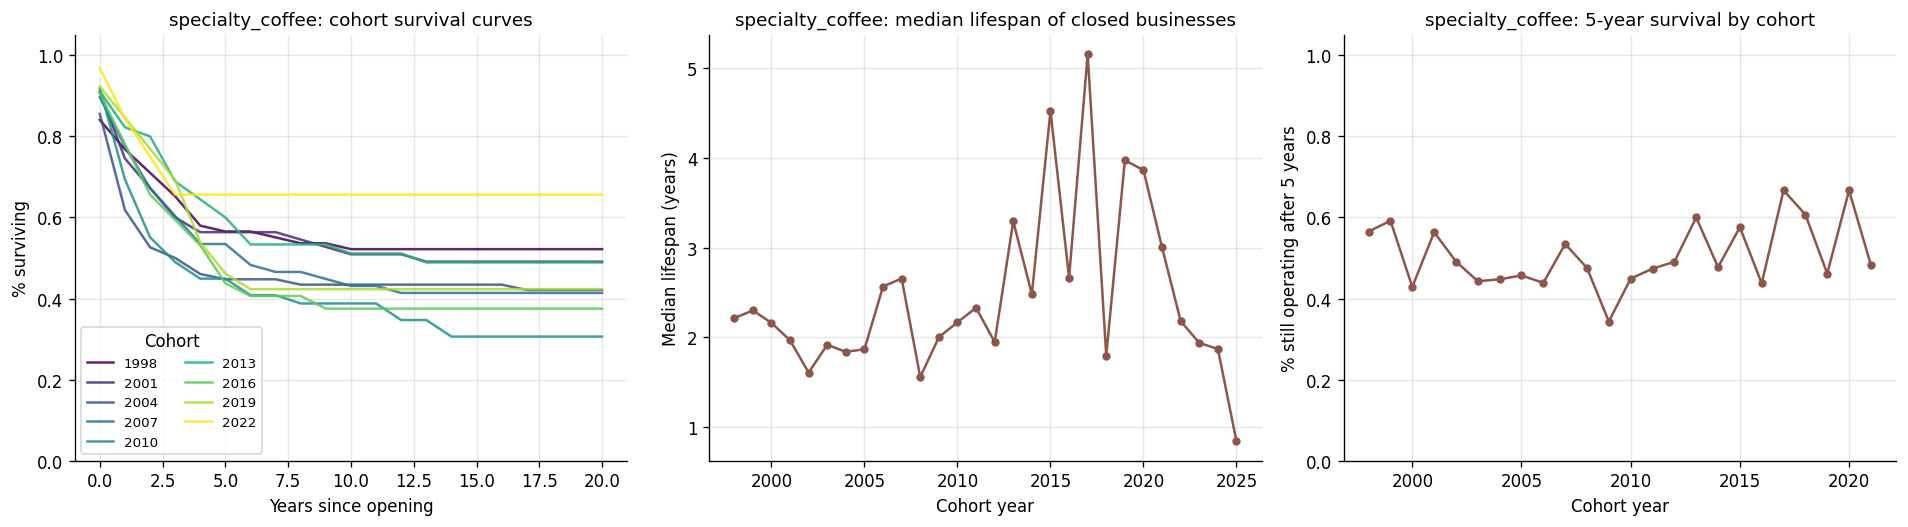

In [5]:
plot_signal_three_views('specialty_coffee', data['specialty_coffee'])

## Wine bars

Caveat: 25 unique businesses after the strict name filter. The signal's recall is low; treat as a high-precision lower bound. Survival curves will be jagged.

  saved analysis/composite_index/weekend_2_charts/wine_bars_survival.png


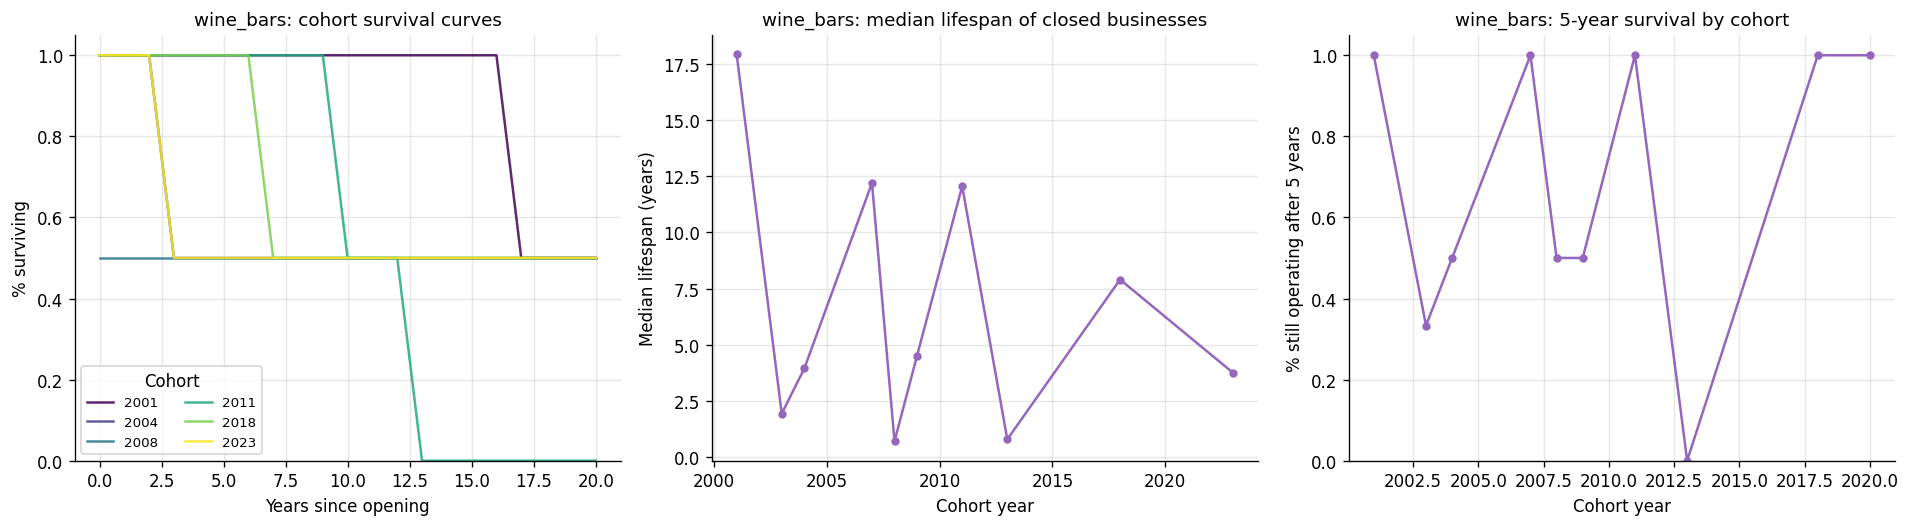

In [6]:
plot_signal_three_views('wine_bars', data['wine_bars'], cohort_step=2, min_cohort_size=2)

## Pilates studios

  saved analysis/composite_index/weekend_2_charts/pilates_studios_survival.png


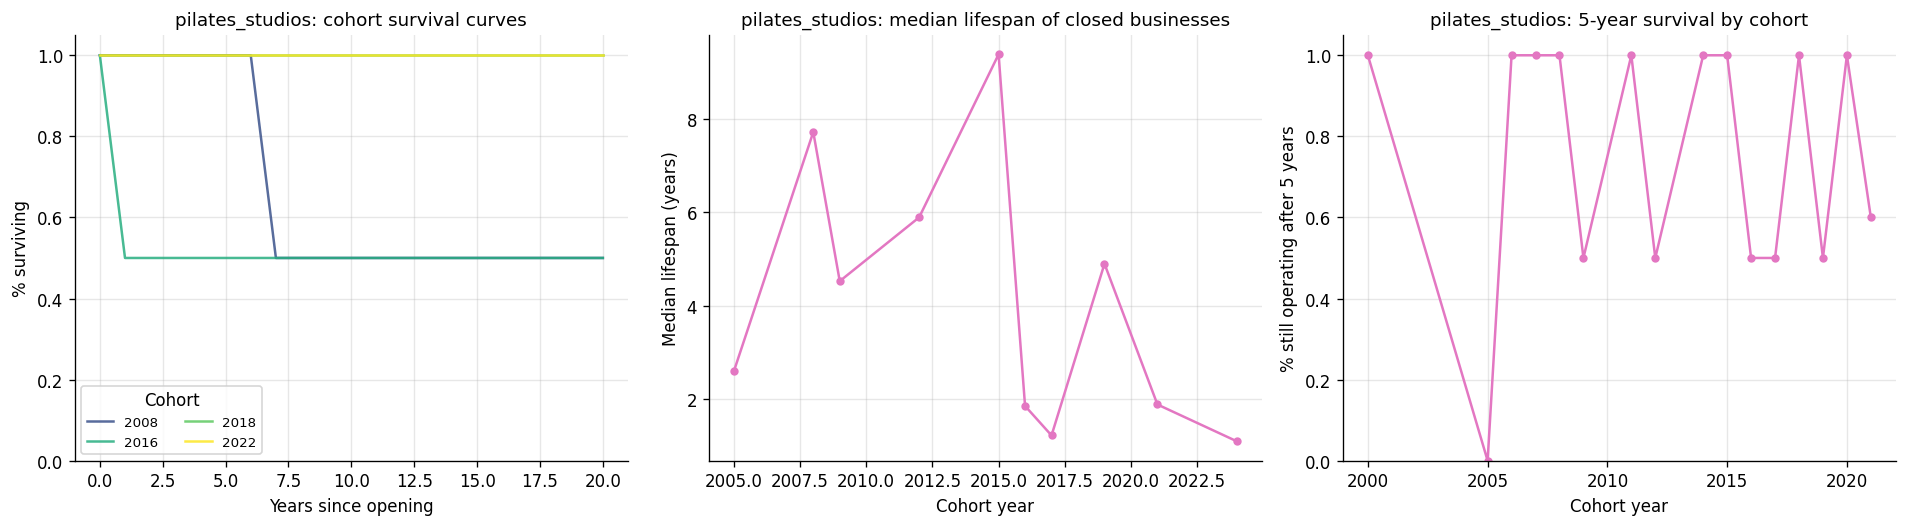

In [7]:
plot_signal_three_views('pilates_studios', data['pilates_studios'], cohort_step=2, min_cohort_size=2)

## Auto repair

  saved analysis/composite_index/weekend_2_charts/auto_repair_survival.png


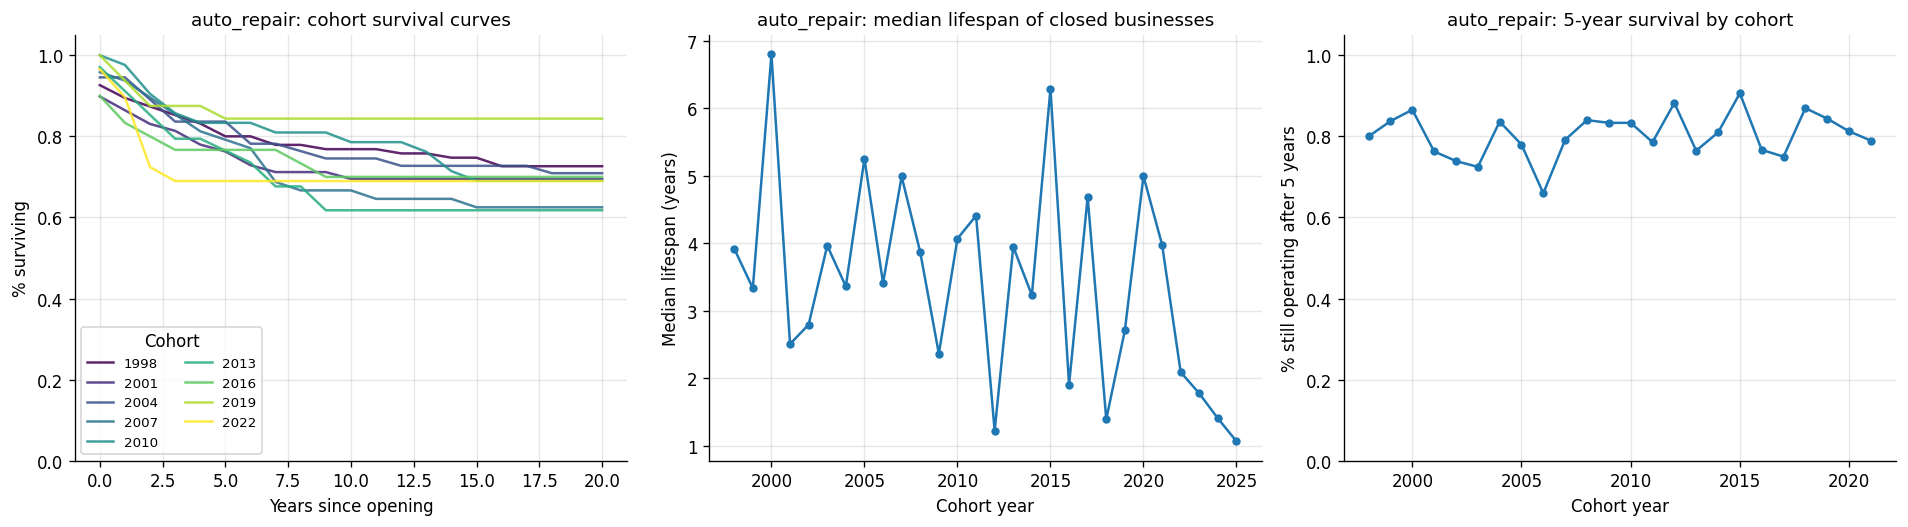

In [8]:
plot_signal_three_views('auto_repair', data['auto_repair'])

## Print shops

  saved analysis/composite_index/weekend_2_charts/print_shops_survival.png


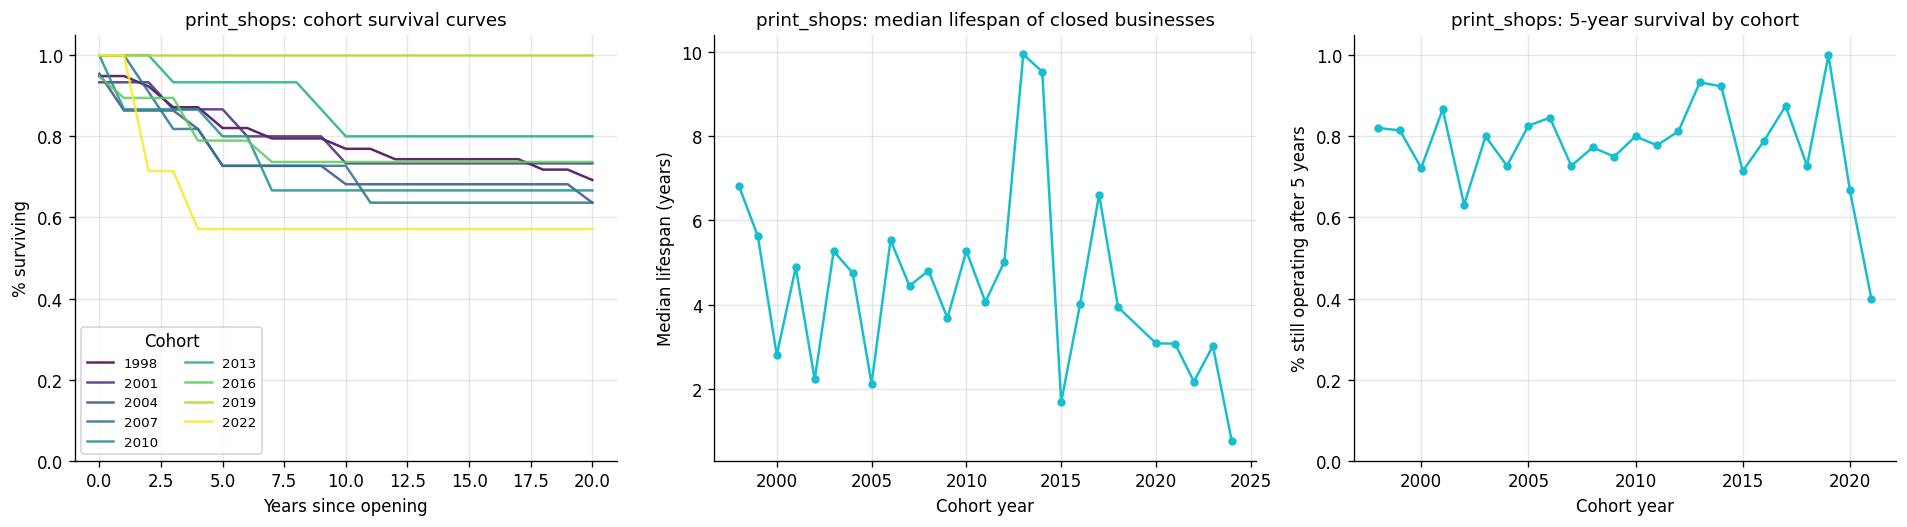

In [9]:
plot_signal_three_views('print_shops', data['print_shops'])

## Whole Foods

Three businesses total (Cambie, Robson, Kitsilano). Survival curves are essentially per-business histories. Included for completeness; the value is in the cross-signal comparison below, not in the curves themselves.

  saved analysis/composite_index/weekend_2_charts/whole_foods_openings_survival.png


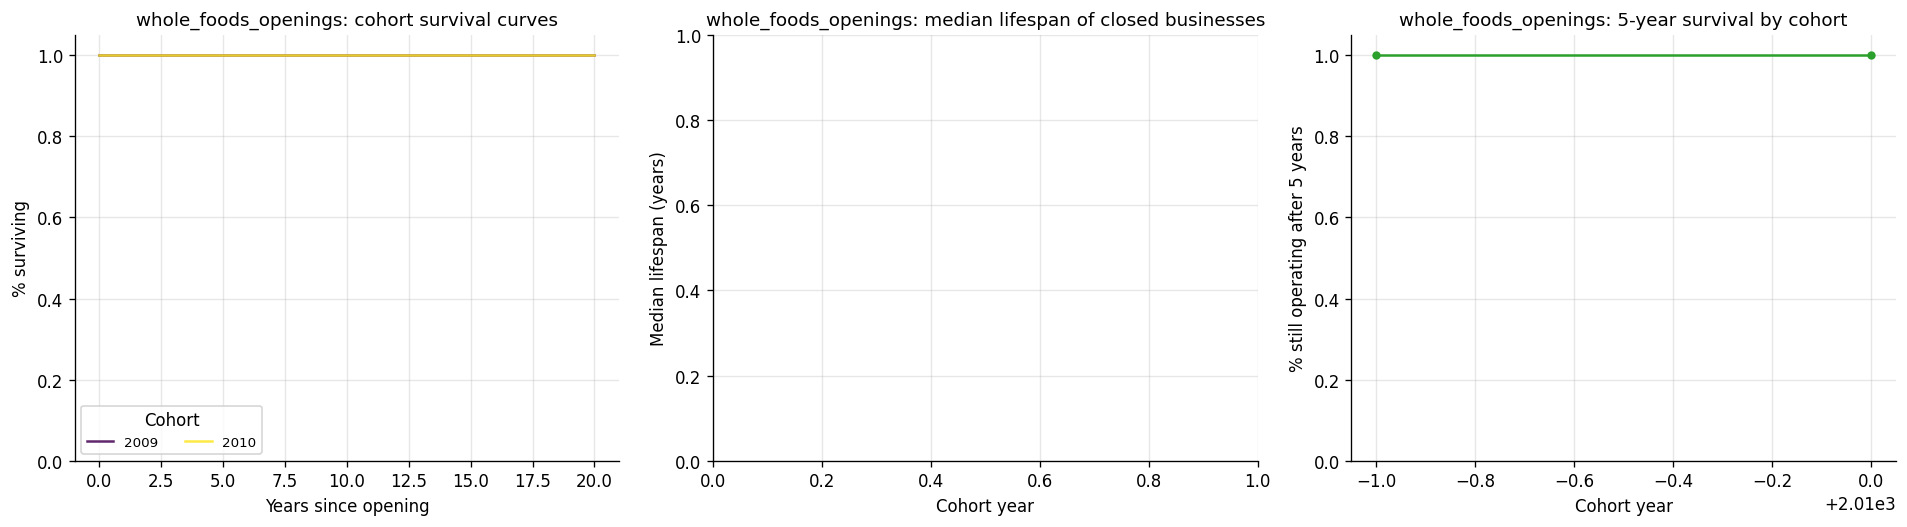

In [10]:
plot_signal_three_views('whole_foods_openings', data['whole_foods_openings'], cohort_step=1, min_cohort_size=1)

## Cross-signal comparison: 5-year survival by signal type

Two hypotheses to check:
1. Counter-signals have longer-lived cohorts than leading-signals (incumbent businesses are stickier than gentrification-frontier businesses).
2. Leading-signal cohort survival declines over time as categories saturate.

  saved analysis/composite_index/weekend_2_charts/cross_signal_5yr_survival.png


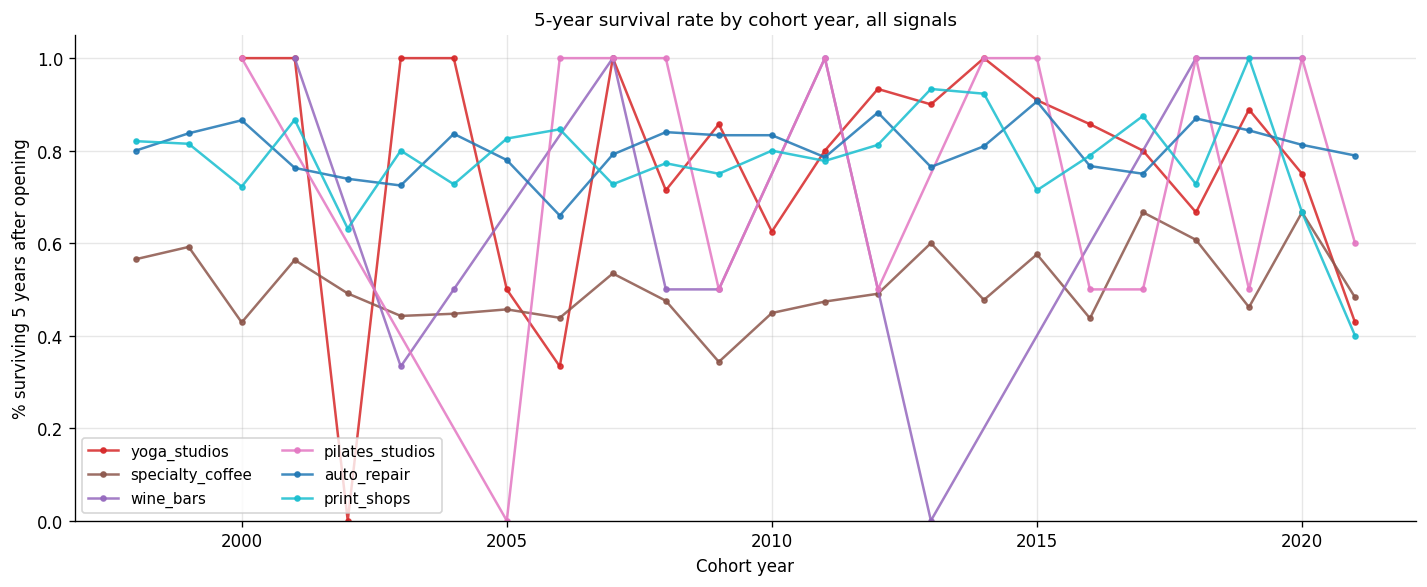

In [11]:
fig, ax = plt.subplots(figsize=(12, 5))
for name, df in data.items():
    surv = n_year_survival_rate(df, n_years=5)
    if surv.height < 5:
        continue
    ax.plot(surv['cohort_year'], surv['pct_surviving_at_n'],
            label=name, color=signal_color(name), marker='o', markersize=3, alpha=0.85)
ax.set_title('5-year survival rate by cohort year, all signals')
ax.set_xlabel('Cohort year')
ax.set_ylabel('% surviving 5 years after opening')
ax.set_ylim(0, 1.05)
ax.legend(fontsize=9, loc='lower left', ncol=2)
fig.tight_layout()
out = CHART_DIR / 'cross_signal_5yr_survival.png'
fig.savefig(out, bbox_inches='tight')
print(f'  saved {out.relative_to(ROOT)}')
plt.show()

shape: (7, 5)
┌──────────────────────┬─────────┬───────┬─────────────────┬──────────────────┐
│ signal               ┆ class   ┆ total ┆ alive_after_5yr ┆ pct_5yr_survival │
│ ---                  ┆ ---     ┆ ---   ┆ ---             ┆ ---              │
│ str                  ┆ str     ┆ i64   ┆ i64             ┆ f64              │
╞══════════════════════╪═════════╪═══════╪═════════════════╪══════════════════╡
│ whole_foods_openings ┆ anchor  ┆ 3     ┆ 3               ┆ 100.0            │
│ auto_repair          ┆ counter ┆ 1102  ┆ 882             ┆ 80.0             │
│ print_shops          ┆ counter ┆ 402   ┆ 318             ┆ 79.1             │
│ yoga_studios         ┆ leading ┆ 123   ┆ 100             ┆ 81.3             │
│ pilates_studios      ┆ leading ┆ 29    ┆ 20              ┆ 69.0             │
│ wine_bars            ┆ leading ┆ 21    ┆ 13              ┆ 61.9             │
│ specialty_coffee     ┆ leading ┆ 1139  ┆ 562             ┆ 49.3             │
└──────────────────────┴──

  saved analysis/composite_index/weekend_2_charts/cross_signal_5yr_survival_pooled.png


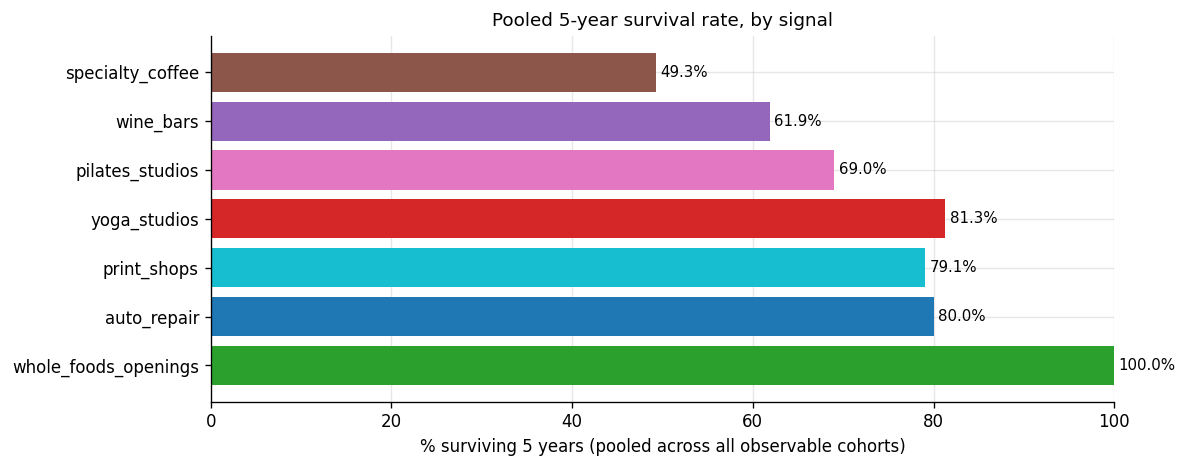

In [12]:
# Pooled 5-year survival across all observable cohorts.
rows = []
for name, df in data.items():
    surv = n_year_survival_rate(df, n_years=5)
    if surv.height == 0:
        continue
    pooled_total = int(surv['n_total'].sum())
    pooled_alive = int(surv['n_surviving_at_n'].sum())
    rows.append({
        'signal': name,
        'class': df['signal_class'].unique().to_list()[0],
        'total': pooled_total,
        'alive_after_5yr': pooled_alive,
        'pct_5yr_survival': round(100 * pooled_alive / pooled_total, 1) if pooled_total else 0,
    })
pooled_df = pl.DataFrame(rows).sort(['class', 'pct_5yr_survival'], descending=[False, True])
print(pooled_df)

fig, ax = plt.subplots(figsize=(10, 4))
names = pooled_df['signal'].to_list()
vals = pooled_df['pct_5yr_survival'].to_list()
colors = [signal_color(n) for n in names]
ax.barh(names, vals, color=colors)
for i, v in enumerate(vals):
    ax.text(v + 0.5, i, f'{v}%', va='center', fontsize=9)
ax.set_title('Pooled 5-year survival rate, by signal')
ax.set_xlabel('% surviving 5 years (pooled across all observable cohorts)')
ax.set_xlim(0, 100)
fig.tight_layout()
out = CHART_DIR / 'cross_signal_5yr_survival_pooled.png'
fig.savefig(out, bbox_inches='tight')
print(f'  saved {out.relative_to(ROOT)}')
plt.show()

## Neighborhood drill-downs

For yoga and specialty coffee, compare cohort survival across three neighborhoods at different points in their gentrification trajectories: Mount Pleasant (early-gentrified), Kitsilano (already gentrified), Marpole (late-gentrification candidate).

Hypothesis: early-cohort survival is higher in early-gentrification neighborhoods (less competition), declining for late-cohorts in the same neighborhoods (saturation), while late-gentrification neighborhoods show the opposite pattern (early cohorts struggle, recent cohorts have a chance).

In [13]:
NEIGHBORHOODS = ['Mount Pleasant', 'Kitsilano', 'Marpole']

def plot_neighborhood_survival(name, df, neighborhoods=NEIGHBORHOODS, bucket_years=5):
    """Cohort survival by neighborhood, with cohorts pooled into N-year buckets so per-
    neighborhood subsamples are large enough to plot. With single-year cohorts most
    neighborhood subsets have <3 businesses per year and the chart goes empty."""
    fig, axes = plt.subplots(1, len(neighborhoods), figsize=(15, 4), sharey=True)
    today_year = date.today().year
    cmap = plt.get_cmap('viridis')
    for ax, hood in zip(axes, neighborhoods):
        sub = df.filter(pl.col('neighborhood') == hood)
        sub = sub.with_columns(
            (pl.col('establishment_date').dt.year() // bucket_years * bucket_years).alias('bucket')
        )
        buckets = sorted(b for b in sub['bucket'].unique().to_list() if b <= today_year - 3)
        for i, b in enumerate(buckets):
            cohort = sub.filter(pl.col('bucket') == b)
            if cohort.height < 3:
                continue
            # Use the bucket's earliest year as the survival reference; combine the cohort.
            n_at_risk = cohort.height
            offsets, pcts = [], []
            for offset in range(21):
                cutoff = date(int(b) + offset, 12, 31)
                still = cohort.filter(
                    pl.col('closure_date').is_null() | (pl.col('closure_date') > cutoff)
                ).height
                offsets.append(offset)
                pcts.append(still / n_at_risk)
            label = f"{int(b)}-{int(b) + bucket_years - 1} (n={n_at_risk})"
            ax.plot(offsets, pcts, label=label, color=cmap(i / max(1, len(buckets) - 1)), alpha=0.85)
        ax.set_title(f'{hood} (n={sub.height})')
        ax.set_xlabel('Years since opening')
        ax.set_ylim(0, 1.05)
        if any(c.height >= 3 for c in [sub.filter(pl.col('bucket') == b) for b in buckets]):
            ax.legend(fontsize=7, loc='lower left', title=f'{bucket_years}-yr cohort')
    axes[0].set_ylabel('% surviving')
    fig.suptitle(f'{name}: cohort survival by neighborhood ({bucket_years}-year buckets)')
    fig.tight_layout()
    out = CHART_DIR / f'{name}_neighborhood_survival.png'
    fig.savefig(out, bbox_inches='tight')
    print(f'  saved {out.relative_to(ROOT)}')
    plt.show()

  saved analysis/composite_index/weekend_2_charts/yoga_studios_neighborhood_survival.png


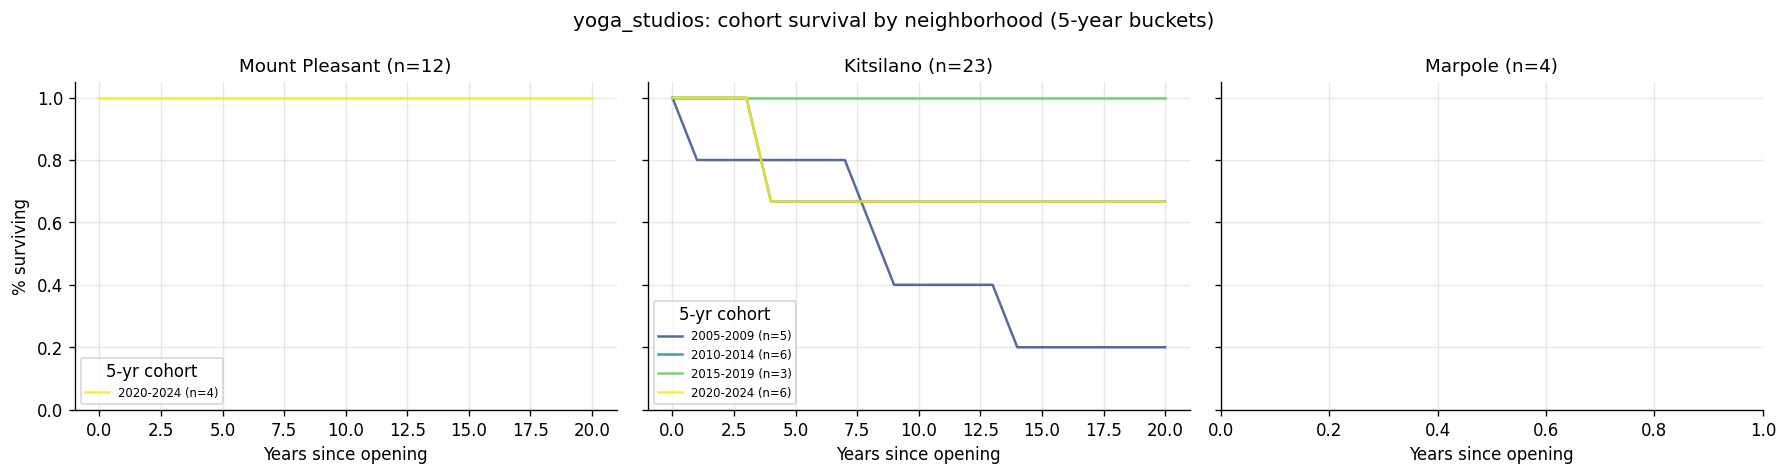

In [14]:
plot_neighborhood_survival('yoga_studios', data['yoga_studios'])

  saved analysis/composite_index/weekend_2_charts/specialty_coffee_neighborhood_survival.png


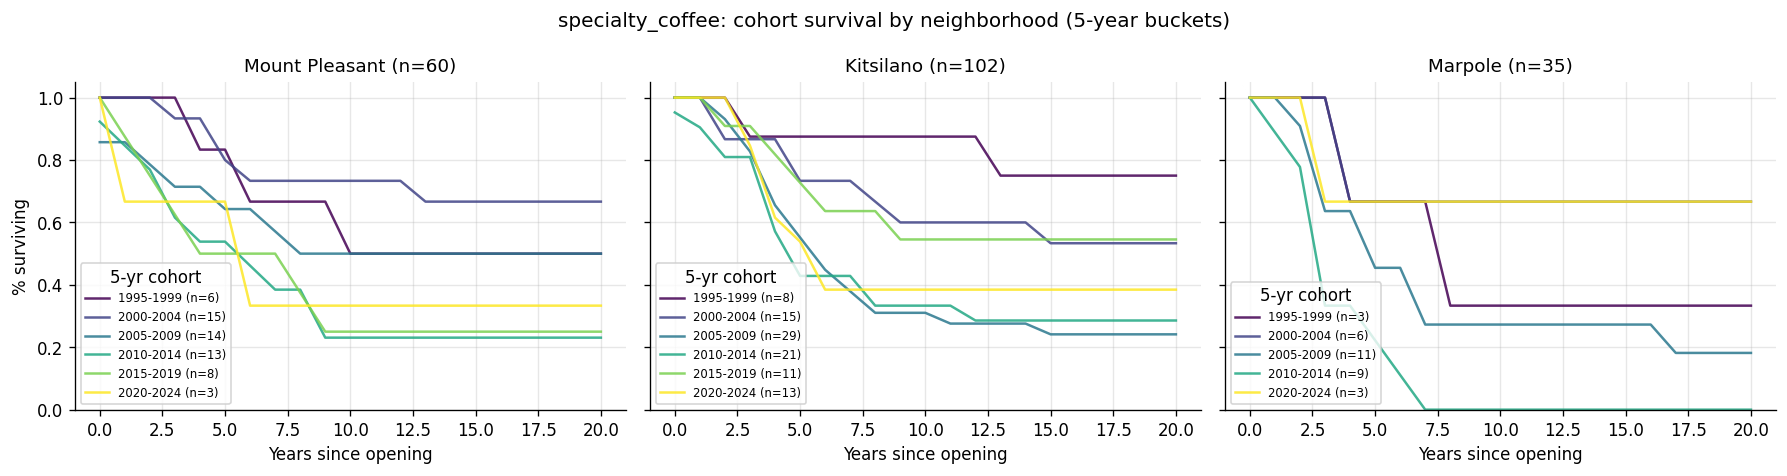

In [15]:
plot_neighborhood_survival('specialty_coffee', data['specialty_coffee'])

## Findings

(This section is filled in by the analyst after looking at the charts above. The Weekend 2 batch-1 build leaves it as a template; the actual prose findings go into the report that wraps the notebook execution, not into the notebook itself, so this cell is intentionally light.)

Things to look for when reading the charts:

1. **Cross-signal pooled survival.** Do counter-signals (auto repair, print shops) sit visibly above the leading-signals on 5-year survival? If yes, the incumbent-stickiness hypothesis holds. If not, the closure heuristic's under-counting may be hiding the gap.
2. **Cohort-by-cohort 5-year survival trends.** For leading signals, is there a downward slope as recent cohorts replace early ones (saturation)? For counter signals, is there an upward slope as the surviving incumbents are increasingly the resilient ones?
3. **Neighborhood divergence.** For yoga and coffee, does Mount Pleasant show declining cohort survival over time (early adopters thrived, late entrants competed against an already-saturated market) while Marpole shows the opposite (early entrants struggled, recent ones do better)?

Write findings into the project's analysis output once charts are reviewed.